## Setup

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.status()

  Activating project at `~/WignerMolecule.jl/analysis`


Status `~/WignerMolecule.jl/analysis/Project.toml`
  [13f3f980] CairoMakie v0.15.9
⌃ [780c37f4] Carlo v0.2.6
  [074ae576] CarloAnalysis v1.0.0-DEV `https://github.com/PatXue/CarloAnalysis.jl#main`
  [a93c6f00] DataFrames v1.8.1
  [f67ccb44] HDF5 v0.17.2
  [033835bb] JLD2 v0.6.3
  [ebeed567] PeriodicArrays v0.1.0 `https://github.com/PatXue/PeriodicArrays.jl#main`
  [90137ffa] StaticArrays v1.9.18
Info Packages marked with ⌃ have new versions available and may be upgradable.


In [2]:
using CairoMakie
using Carlo.ResultTools
using CarloAnalysis
using DataFrames
using HDF5
using JLD2
using LinearAlgebra

In [3]:
function etak_tranform(etak_corrs)
    result = map(Iterators.product(1:3, 1:3)) do (x, y)
        etak_corrs[:, :, x, y]
    end
    return reshape(result, (9,))
end

function separate_etaks!(data::AbstractDataFrame)
    col_names = [:ηk_xx, :ηk_yx, :ηk_zx, :ηk_xy, :ηk_yy, :ηk_zy, :ηk_xz, :ηk_yz, :ηk_zz]
    transform!(
        data,
        :etak_corrs => (corrs -> etak_tranform.(corrs)) => col_names
    )
    return nothing
end

separate_etaks! (generic function with 1 method)

In [4]:
get_M_point(corrs) = corrs[size(corrs, 1) ÷ 2 + 1]

get_M_point (generic function with 1 method)

In [5]:
function gen_path(Lx, Ly)
    pos = (1, 1)
    path = [pos]
    while pos[1] < div(Lx, 2) + 1
        pos = pos .+ (1, 0)
        push!(path, pos)
    end
    M_pos = length(path)
    while pos[2] < div(Ly, 3, RoundNearest) + 1
        pos = pos .+ (1, 2)
        push!(path, pos)
    end
    K_pos = length(path)
    while pos[1] > 2
        pos = pos .- (2, 1)
        push!(path, pos)
    end
    return (path, M_pos, K_pos)
end

gen_path (generic function with 1 method)

In [6]:
function generatePlot(data::AbstractDataFrame, x, y;
                      title="", xlabel="", ylabel="", line=false)
    ax = Axis(fig; title, xlabel, ylabel)

    vals = getfield.(data[:, y], :val)
    errs = getfield.(data[:, y], :err)
    scatter!(data[:, x], vals)
    if line
        lines!(data[:, x], vals)
    end
    errorbars!(data[:, x], vals, errs)

    return ax
end

function generatePlot(data::AbstractDataFrame, x, ys::Vector;
                      title="", xlabel="", ylabel="", line=false)
    ax = Axis(fig; title, xlabel, ylabel)

    for (label, y) in zip(ys, eachcol(data[:, ys]))
        vals = getfield.(y, :val)
        errs = getfield.(y, :err)
        scatter!(data[:, x], vals; label="$label")
        if line
            lines!(data[:, x], vals)
        end
        errorbars!(data[:, x], vals, errs)
    end
    axislegend()

    return ax
end

function generatePlot(data::GroupedDataFrame, x, y;
                      title, xlabel, ylabel, line=false)
    ax = Axis(fig; title, xlabel, ylabel)

    for key in keys(data)
        group = data[key]
        vals = getfield.(group[:, y], :val)
        errs = getfield.(group[:, y], :err)
        scatter!(group[:, x], vals, label="$(NamedTuple(key))")
        if line
            lines!(group[:, x], vals)
        end
        errorbars!(group[:, x], vals, errs)
    end

    axislegend()

    return ax
end

generatePlot (generic function with 3 methods)

## Left Phase Patch Zero Field

In [7]:
results = JobResult("../jobs", "afm-afe-left")
results

JobResult("../jobs", "afm-afe-left", 60×54 DataFrame
 Row │ ηk_Γ                               ηk_corr_half_K                     M ⋯
     │ Array…                             Array…                             M ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  - ⋯
   2 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…
   3 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…
   4 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…
   5 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  - ⋯
   6 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…
   7 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…
   8 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…
  ⋮  │                 ⋮                                  ⋮                    ⋱
  54 

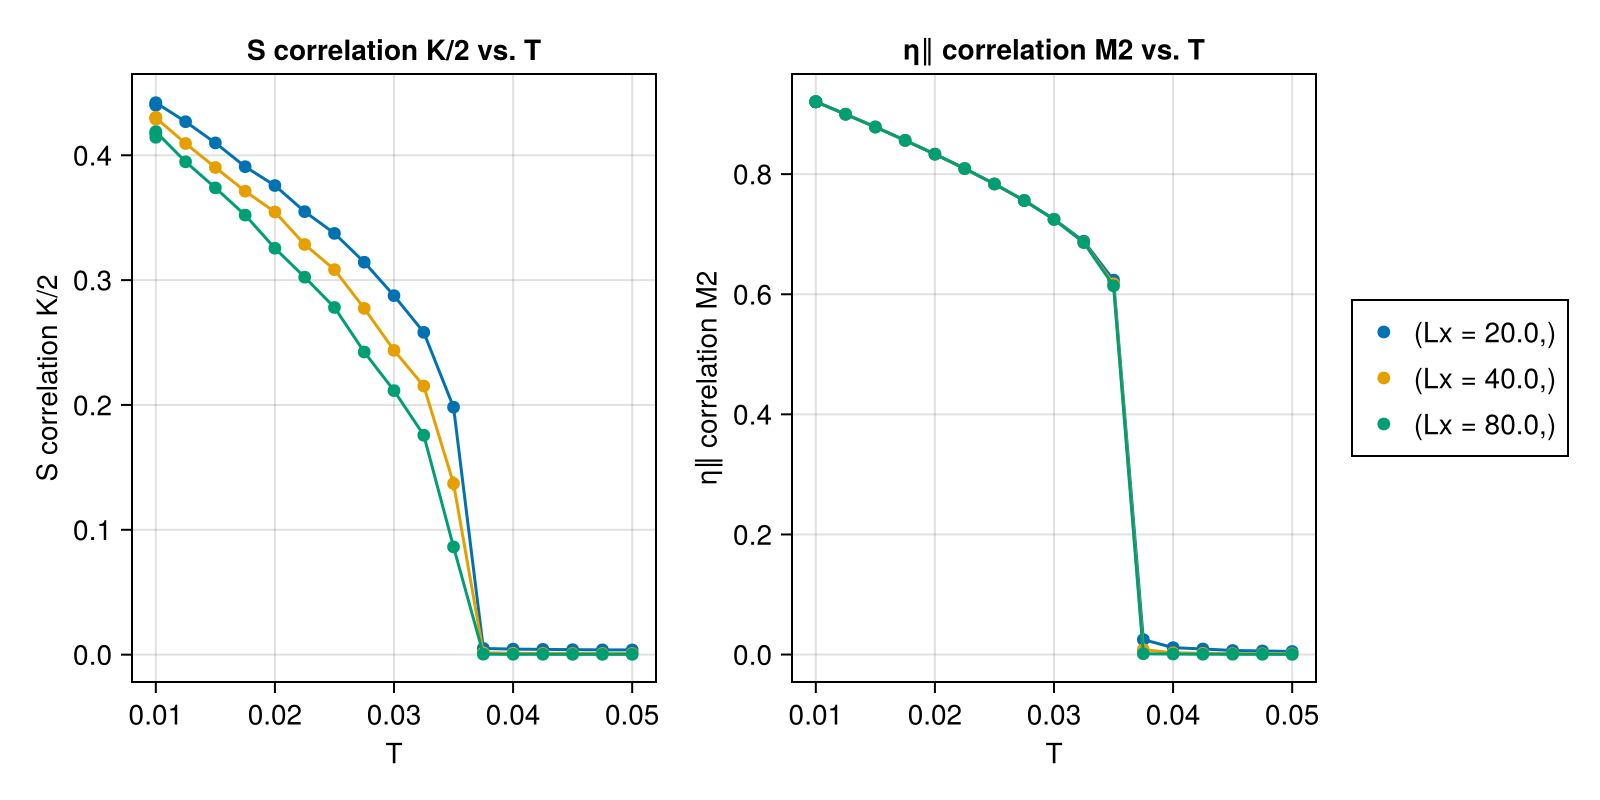

In [8]:
CairoMakie.activate!()

fig = Figure(size=(800, 400))
ax1 = fig[1,1] = Axis(fig, title="S correlation K/2 vs. T", xlabel="T", ylabel="S correlation K/2")
# scatter!(ax1, results[:B], M_points)
# lines!(ax1, results[:B], M_points)
generate_plot!(ax1, :T, :sk_corr_half_K, [:Lx], results.data; line=true)
fig[1,2] = ax2 = Axis(fig, title="η∥ correlation M2 vs. T", xlabel="T", ylabel="η∥ correlation M2")
generate_plot!(ax2, :T, :ηk_corr_M2, [:Lx], results.data; line=true) do ηk
    real.(getindex.(ηk, 1, 1) + getindex.(ηk, 2, 2))
end
Legend(fig[1,3], ax2)
save("afm_afe_mag.png", fig)
fig

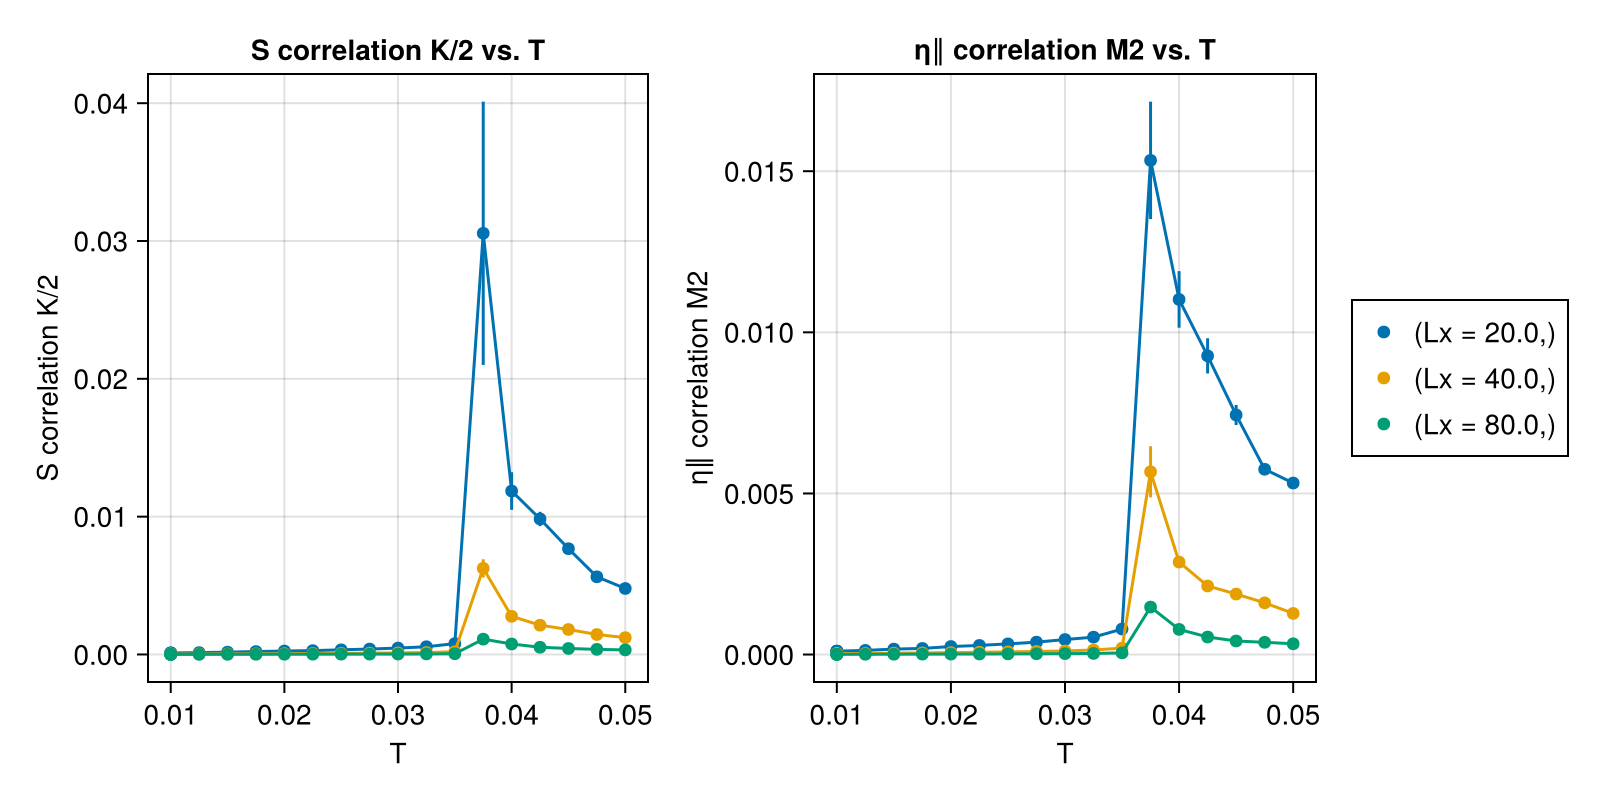

In [9]:
CairoMakie.activate!()

fig = Figure(size=(800, 400))
ax1 = fig[1,1] = Axis(fig, title="S correlation K/2 vs. T", xlabel="T", ylabel="S correlation K/2")
# scatter!(ax1, results[:B], M_points)
# lines!(ax1, results[:B], M_points)
generate_plot!(ax1, :T, :ηk_corr_M, [:Lx], results.data; line=true) do ηk
    real.(getindex.(ηk, 1, 1) + getindex.(ηk, 2, 2))
end
fig[1,2] = ax2 = Axis(fig, title="η∥ correlation M2 vs. T", xlabel="T", ylabel="η∥ correlation M2")
generate_plot!(ax2, :T, :ηk_corr_M3, [:Lx], results.data; line=true) do ηk
    real.(getindex.(ηk, 1, 1) + getindex.(ηk, 2, 2))
end
Legend(fig[1,3], ax2)
fig

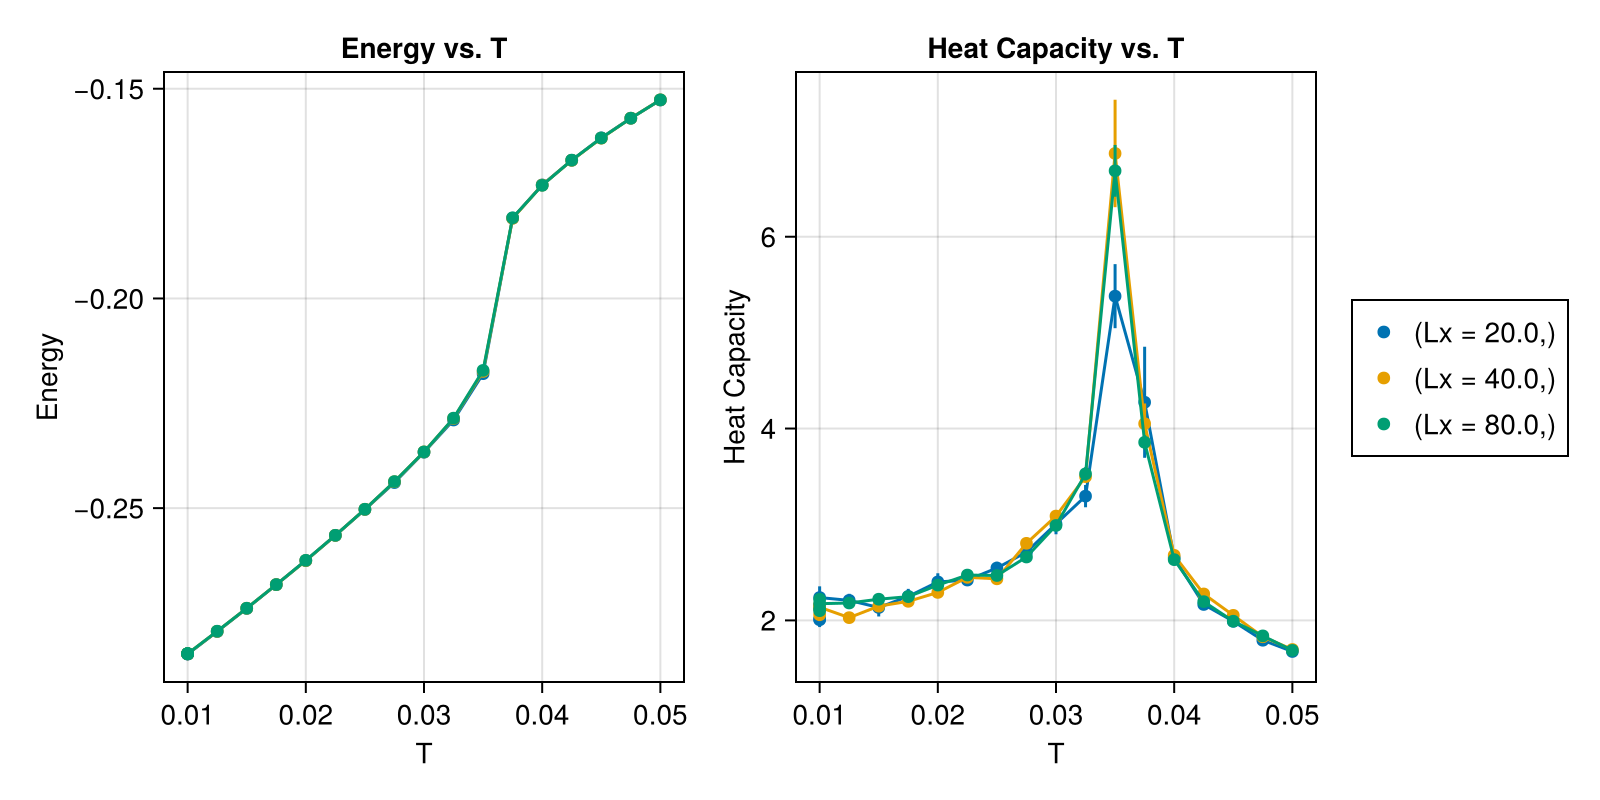

In [10]:
fig = Figure(size=(800, 400))
ax1 = fig[1,1] = Axis(fig, title="Energy vs. T", xlabel="T", ylabel="Energy")
generate_plot!(ax1, :T, :Energy, [:Lx], results.data; line=true)
ax2 = fig[1,2] = Axis(fig, title="Heat Capacity vs. T", xlabel="T", ylabel="Heat Capacity")
generate_plot!(ax2, :T, :HeatCap, [:Lx], results.data; line=true)
Legend(fig[1,3], ax1)
save("plots/afm_afe_energy.png", fig)
fig

In [11]:
mctimes = get_mctime_data(results, :sk_corr_half_K, :ηk_corr_M2)
nothing

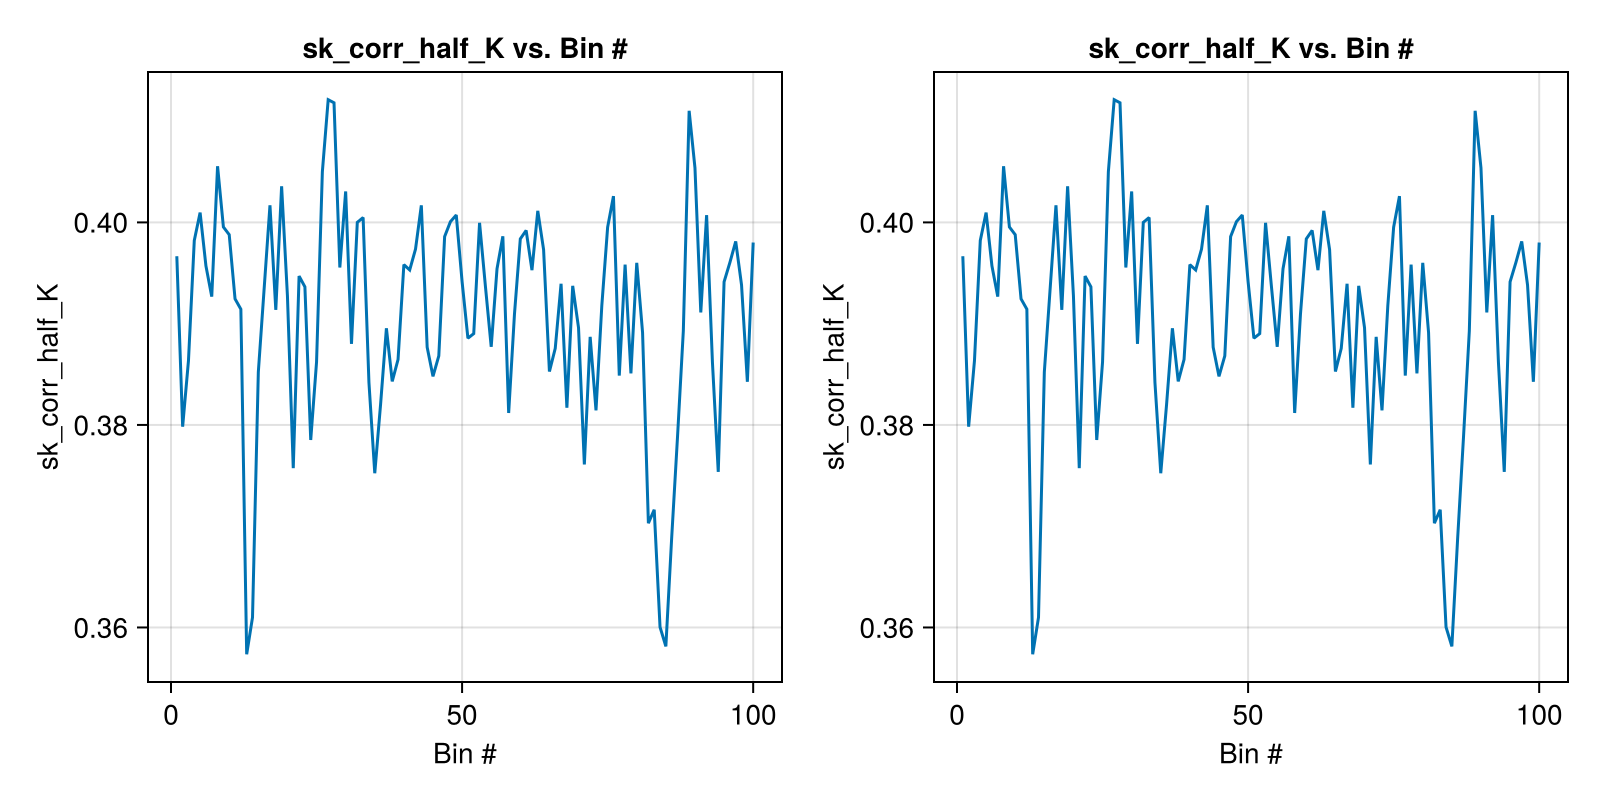

In [12]:
CairoMakie.activate!()
i = 7

var1 = :sk_corr_half_K
var2 = :sk_corr_half_K
fig = Figure(size=(800, 400))
fig[1,1] = ax1 = Axis(fig, title="$var1 vs. Bin #", xlabel="Bin #", ylabel="$var1")
fig[1,2] = ax2 = Axis(fig, title="$var2 vs. Bin #", xlabel="Bin #", ylabel="$var2")
lines!(ax1, abs.(first.(mctimes[i][:, var1])))
lines!(ax2, abs.(first.(mctimes[i][:, var2])))
fig

## Left Phase Patch Zero Field Random Init

In [13]:
results = JobResult("../jobs", "afm-afe-left-rand")
results

JobResult("../jobs", "afm-afe-left-rand", 12×56 DataFrame
 Row │ ηk_Γ                               ηk_corr_half_K                     η ⋯
     │ Array…                             Array…                             M ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…    ⋯
   2 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
   3 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
   4 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…  -
   5 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…    ⋯
   6 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…
   7 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…
   8 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
   9 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64

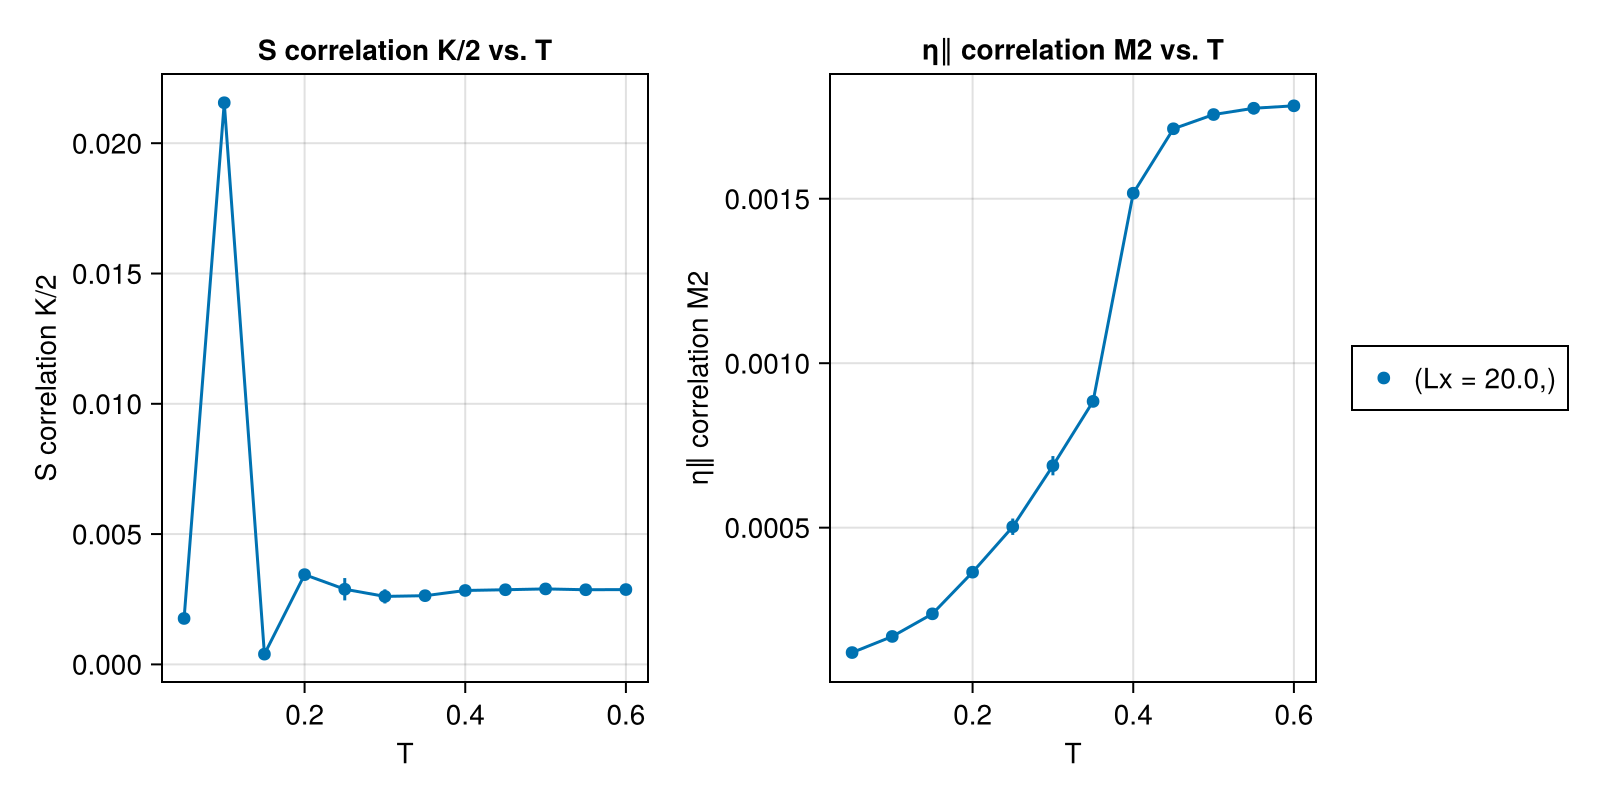

In [14]:
CairoMakie.activate!()

fig = Figure(size=(800, 400))
ax1 = fig[1,1] = Axis(fig, title="S correlation K/2 vs. T", xlabel="T", ylabel="S correlation K/2")
# scatter!(ax1, results[:B], M_points)
# lines!(ax1, results[:B], M_points)
generate_plot!(ax1, :T, :sk_corr_half_K, [:Lx], results.data; line=true)
fig[1,2] = ax2 = Axis(fig, title="η∥ correlation M2 vs. T", xlabel="T", ylabel="η∥ correlation M2")
generate_plot!(ax2, :T, :ηk_corr_M2, [:Lx], results.data; line=true) do ηk
    real.(getindex.(ηk, 1, 1) + getindex.(ηk, 2, 2))
end
Legend(fig[1,3], ax2)
fig

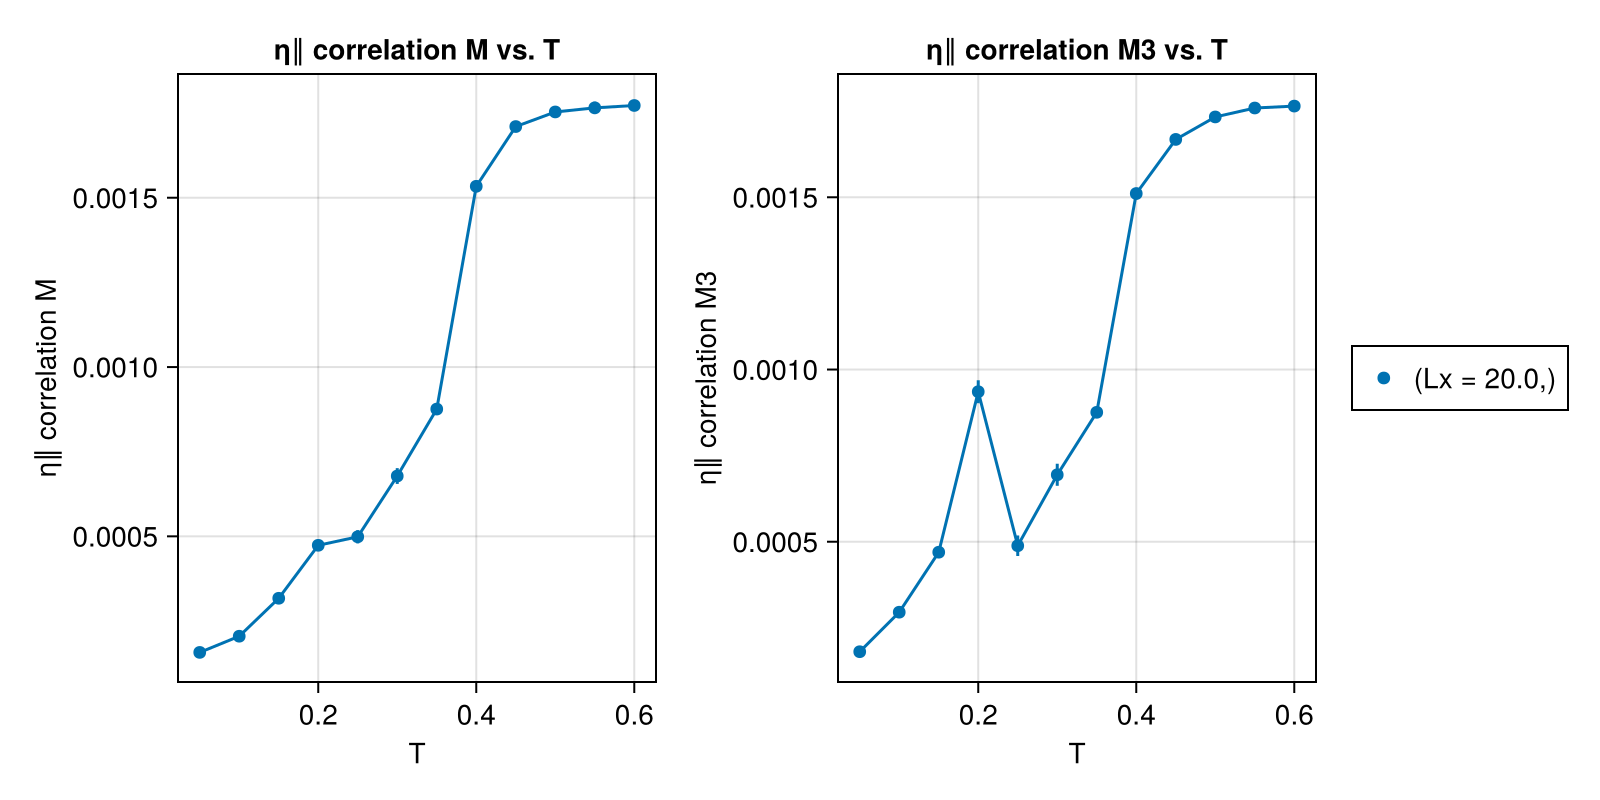

In [19]:
CairoMakie.activate!()

fig = Figure(size=(800, 400))
ax1 = fig[1,1] = Axis(fig, title="η∥ correlation M vs. T", xlabel="T", ylabel="η∥ correlation M")
# scatter!(ax1, results[:B], M_points)
# lines!(ax1, results[:B], M_points)
generate_plot!(ax1, :T, :ηk_corr_M, [:Lx], results.data; line=true) do ηk
    real.(getindex.(ηk, 1, 1) + getindex.(ηk, 2, 2))
end
fig[1,2] = ax2 = Axis(fig, title="η∥ correlation M3 vs. T", xlabel="T", ylabel="η∥ correlation M3")
generate_plot!(ax2, :T, :ηk_corr_M3, [:Lx], results.data; line=true) do ηk
    real.(getindex.(ηk, 1, 1) + getindex.(ηk, 2, 2))
end
Legend(fig[1,3], ax2)
fig

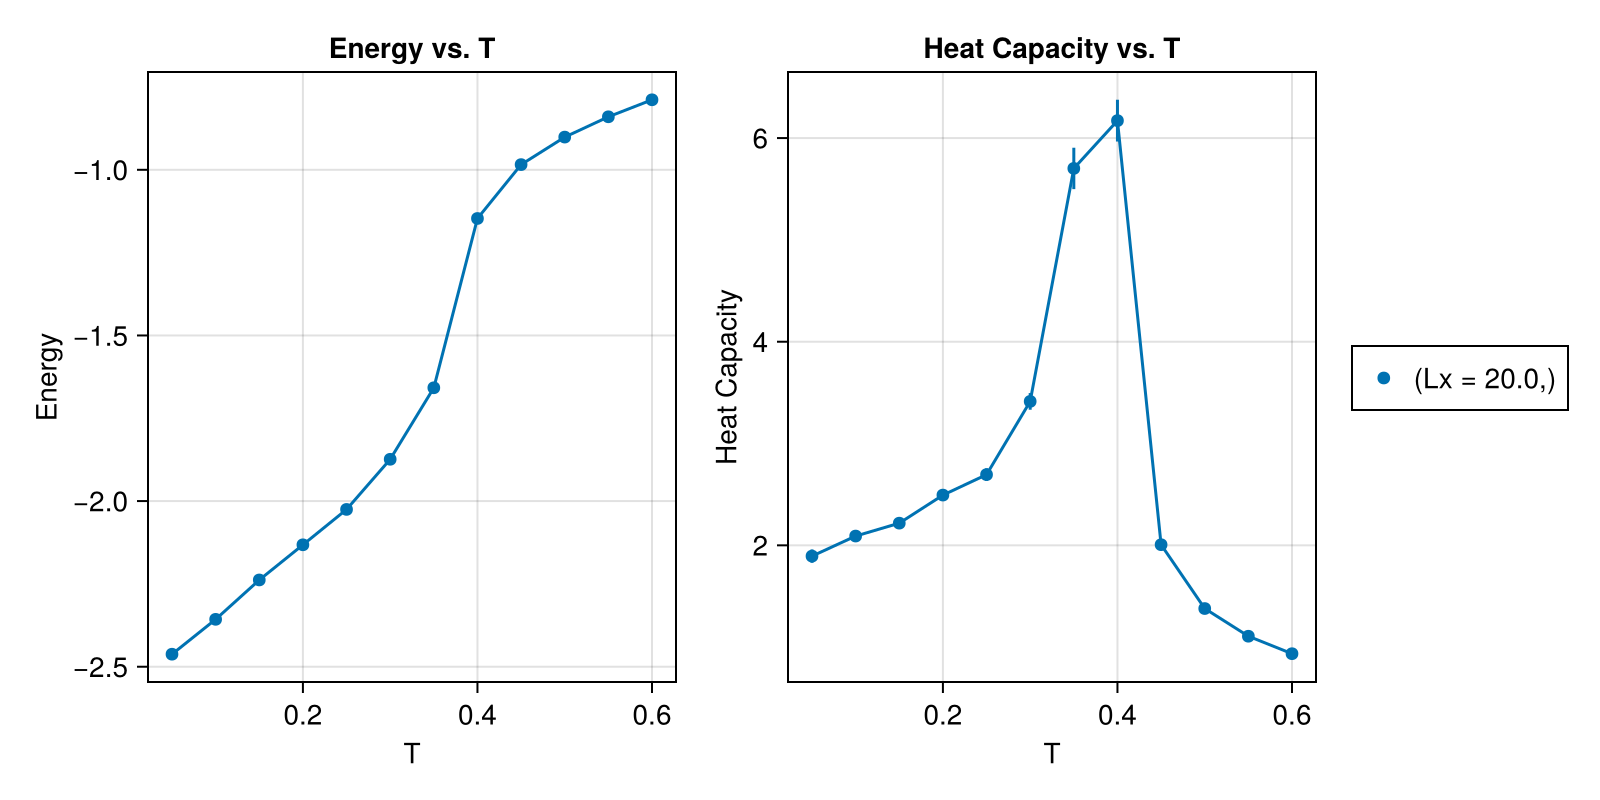

In [16]:
fig = Figure(size=(800, 400))
ax1 = fig[1,1] = Axis(fig, title="Energy vs. T", xlabel="T", ylabel="Energy")
generate_plot!(ax1, :T, :Energy, [:Lx], results.data; line=true)
ax2 = fig[1,2] = Axis(fig, title="Heat Capacity vs. T", xlabel="T", ylabel="Heat Capacity")
generate_plot!(ax2, :T, :HeatCap, [:Lx], results.data; line=true)
Legend(fig[1,3], ax1)
fig

In [17]:
mctimes = get_mctime_data(results, :sk_corr_half_K, :ηk_corr_M2)
nothing

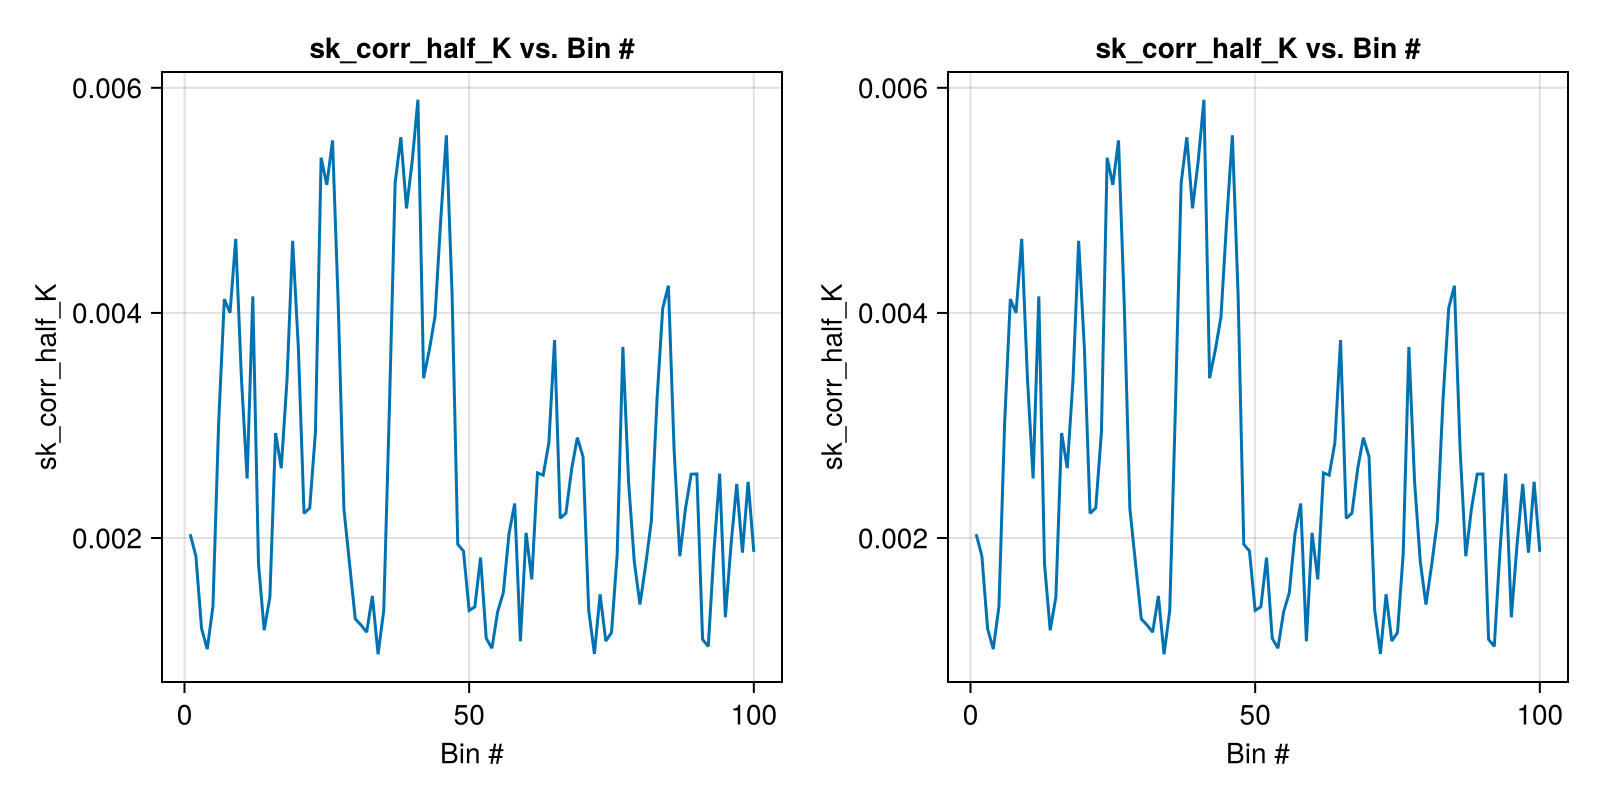

In [18]:
CairoMakie.activate!()
i = 6

var1 = :sk_corr_half_K
var2 = :sk_corr_half_K
fig = Figure(size=(800, 400))
fig[1,1] = ax1 = Axis(fig, title="$var1 vs. Bin #", xlabel="Bin #", ylabel="$var1")
fig[1,2] = ax2 = Axis(fig, title="$var2 vs. Bin #", xlabel="Bin #", ylabel="$var2")
lines!(ax1, abs.(first.(mctimes[i][:, var1])))
lines!(ax2, abs.(first.(mctimes[i][:, var2])))
fig

## Annealed Bias Field

In [13]:
bias_results = JobResult("../jobs", "afm-afe-bias")
bias_results

JobResult("../jobs", "afm-afe-bias", 33×53 DataFrame
 Row │ ηk_Γ                               ηk_corr_half_K                     M ⋯
     │ Array…                             Array…                             M ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ Complex{Measurement{Float64}}[0.…  Complex{Measurement{Float64}}[0.…    ⋯
   2 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…
   3 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
   4 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…
   5 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  - ⋯
   6 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
   7 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
   8 │ Complex{Measurement{Float64}}[-0…  Complex{Measurement{Float64}}[0.…  -
  ⋮  │                 ⋮                                  ⋮               

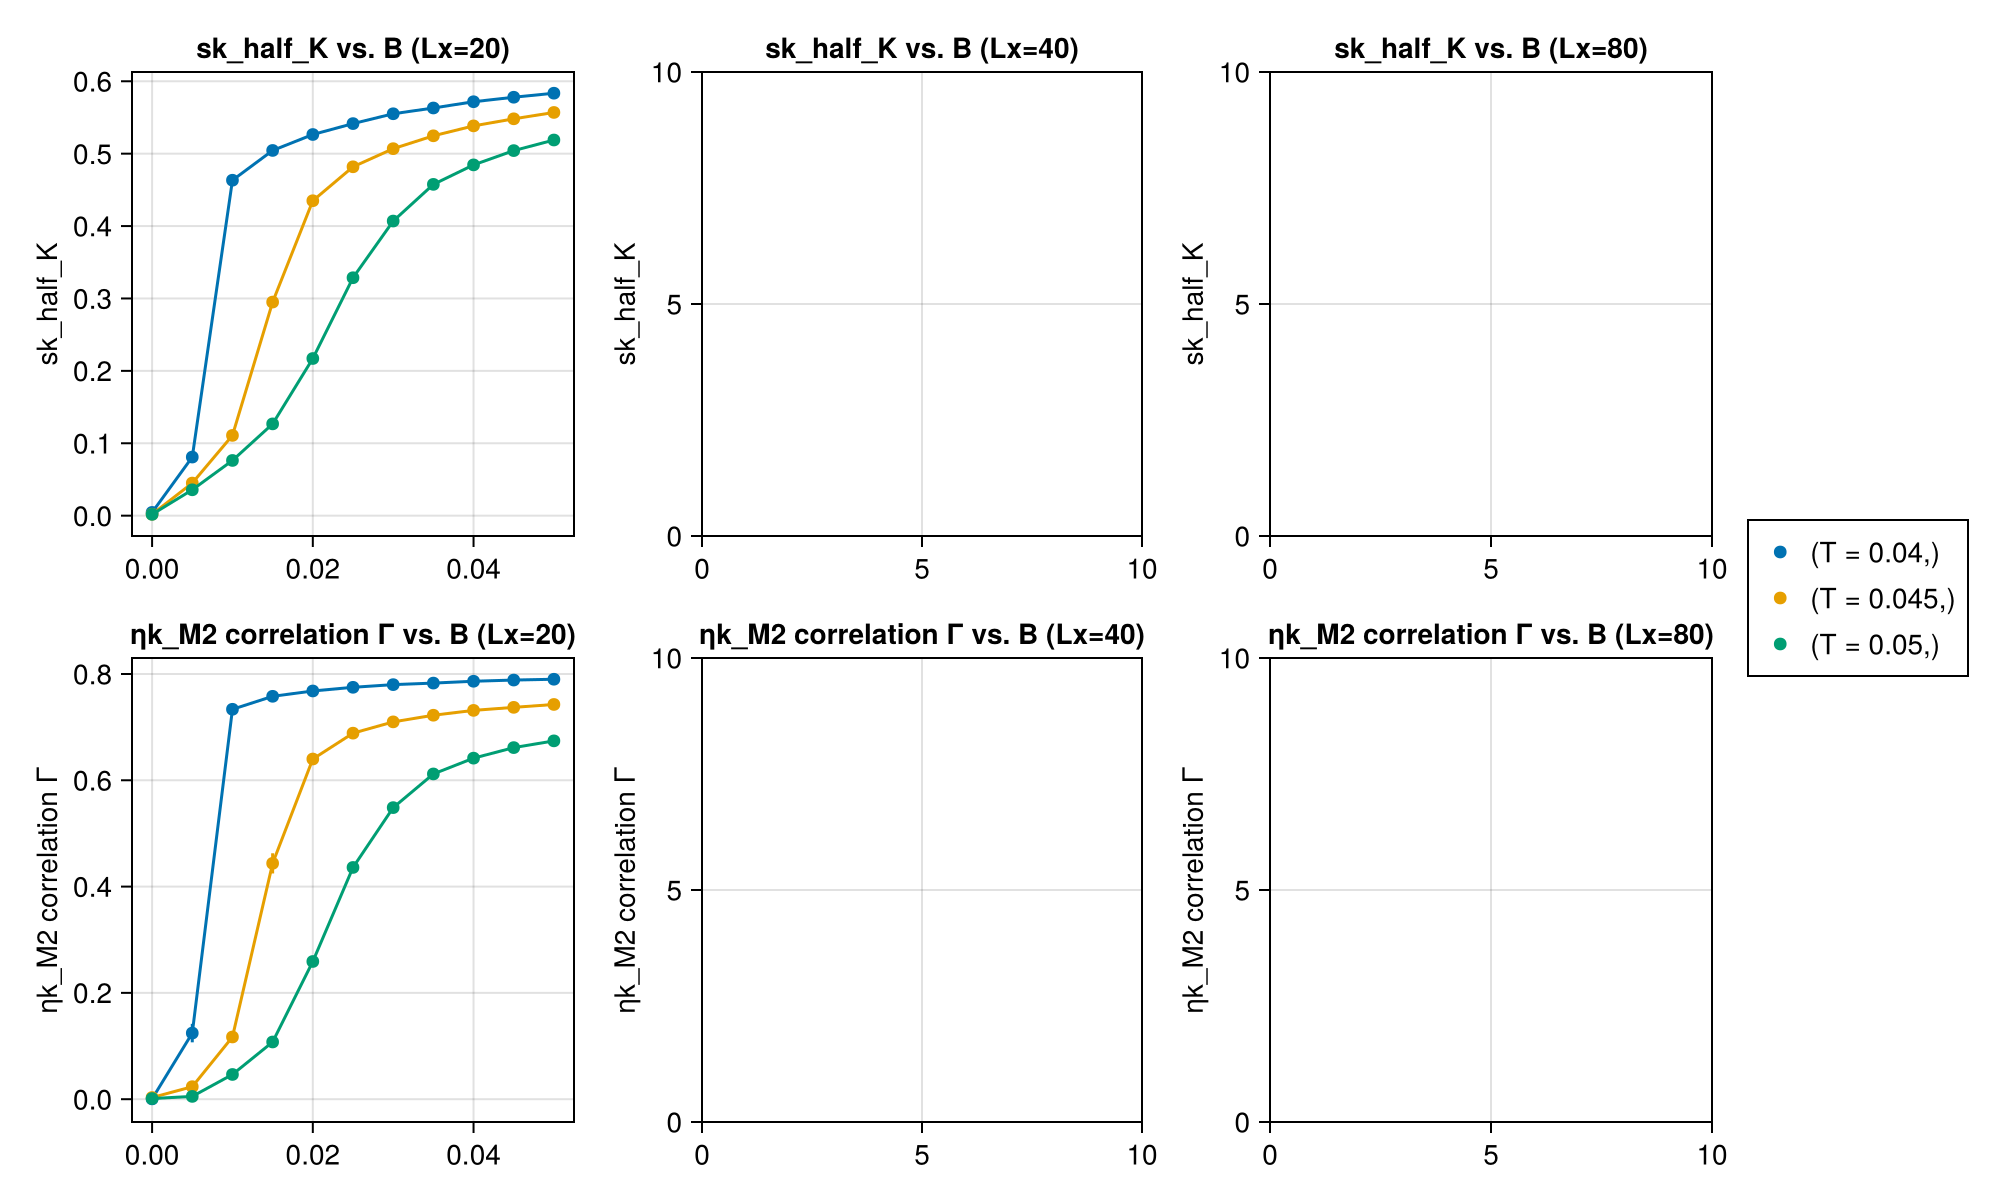

In [14]:
CairoMakie.activate!()
var1 = :sk_half_K
var2 = :ηk_M2
fig = Figure(size=(1000, 600))
axs = []
for i in 1:3
    Lx = 2^i * 10
    fig[1,i] = ax1 = Axis(fig, title="$var1 vs. B (Lx=$Lx)", ylabel="$var1")
    generate_plot!(ax1, :B, var1, [:T], bias_results.data[bias_results.data.Lx .== Lx, :]; line=true) do sk
        norm.(sk)
    end
    fig[2,i] = ax2 = Axis(fig, title="$var2 correlation Γ vs. B (Lx=$Lx)", ylabel="$var2 correlation Γ")
    generate_plot!(ax2, :B, var2, [:T], bias_results.data[bias_results.data.Lx .== Lx, :]; line=true) do ηk
        norm.(ηk)
    end
    push!(axs, ax1)
    push!(axs, ax2)
end
Legend(fig[:,4], first(axs))
save("plots/afm_afe_bias_mag.png", fig)
fig

In [15]:
CairoMakie.activate!()
var1 = :sk_corr_half_K
var2 = :ηk_corr_M2
fig = Figure(size=(1000, 600))
axs = []
for i in 1:3
    Lx = 2^i * 10
    fig[1,i] = ax1 = Axis(fig, title="$var1 vs. B (Lx=$Lx)", ylabel="$var1")
    generate_plot!(ax1, :B, var1, [:T], bias_results.data[bias_results.data.Lx .== Lx, :]; line=true)
    fig[2,i] = ax2 = Axis(fig, title="$var2 correlation Γ vs. B (Lx=$Lx)", ylabel="$var2 correlation Γ")
    generate_plot!(ax2, :B, var2, [:T], bias_results.data[bias_results.data.Lx .== Lx, :]; line=true) do ηz
        real.()
    end
    push!(axs, ax1)
    push!(axs, ax2)
end
Legend(fig[:,4], first(axs))
save("plots/afm_afe_bias_corr.png", fig)
fig

MethodError: MethodError: no method matching real()
The function `real` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  real(!Matched::Type{Union{}}, !Matched::Any...)
   @ Base complex.jl:123
  real(!Matched::ChainRulesCore.ZeroTangent)
   @ ChainRulesCore ~/.julia/packages/ChainRulesCore/Vsbj9/src/tangent_arithmetic.jl:111
  real(!Matched::Missing)
   @ Base missing.jl:101
  ...


In [16]:
CairoMakie.activate!()
var1 = :ChiQ
var2 = :ChiEtaz
fig = Figure(size=(1000, 600))
axs = []
for i in 1:3
    Lx = 2^i * 10
    fig[1,i] = ax1 = Axis(fig, title="$var1 vs. B (Lx=$Lx)", ylabel="$var1")
    generate_plot!(ax1, :B, var1, [:T], bias_results.data[bias_results.data.Lx .== Lx, :]; line=true)
    fig[2,i] = ax2 = Axis(fig, title="$var2 vs. B (Lx=$Lx)", ylabel="$var2")
    generate_plot!(ax2, :B, var2, [:T], bias_results.data[bias_results.data.Lx .== Lx, :]; line=true)
    push!(axs, ax1)
    push!(axs, ax2)
end
Legend(fig[:,4], first(axs))
save("plots/afm_afe_bias_sus.png", fig)
fig

ArgumentError: ArgumentError: column name :ChiQ not found in the data frame

In [17]:
bias_mctimes = get_mctime_data(bias_results, :Mag, :ηz)
nothing

ErrorException: unable to determine if ../jobs/afm-afe-bias.data/task0034/run0001.meas.h5 is accessible in the HDF5 format (file may not exist)

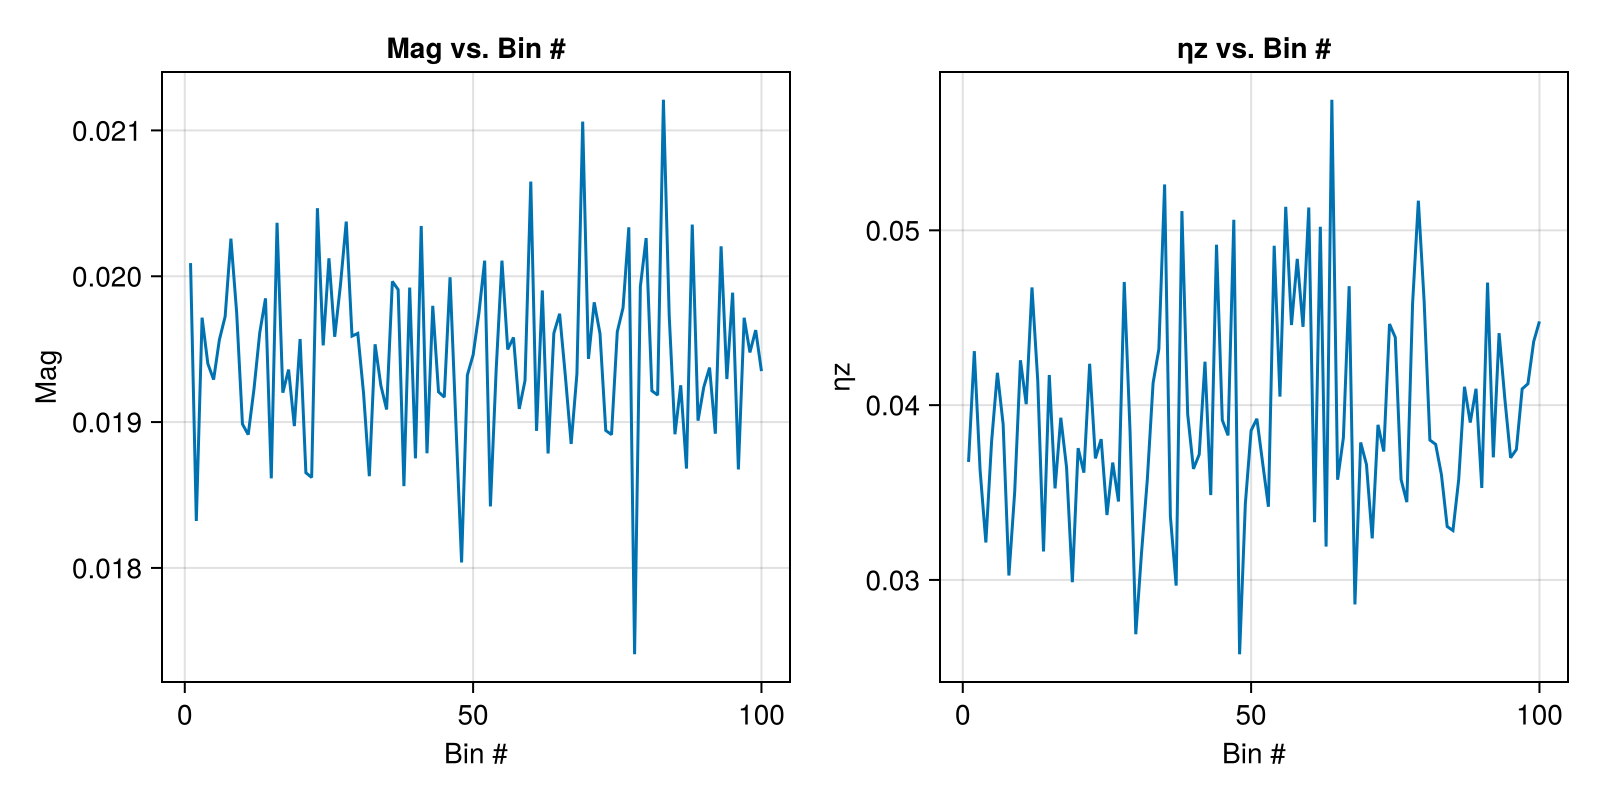

In [18]:
CairoMakie.activate!()
i = 12
k_pos = (1, 1)

var1 = :Mag
var2 = :ηz
fig = Figure(size=(800, 400))
fig[1,1] = ax1 = Axis(fig, title="$var1 vs. Bin #", xlabel="Bin #", ylabel="$var1")
fig[1,2] = ax2 = Axis(fig, title="$var2 vs. Bin #", xlabel="Bin #", ylabel="$var2")
lines!(ax1, abs.(first.(bias_mctimes[i][:, var1])))
lines!(ax2, abs.(first.(bias_mctimes[i][:, var2])))
fig